In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT)
)

In [2]:
import pandas as pd

from src.pricing.valuation import (
    value_portfolio,
)

portfolio_risk = value_portfolio()

portfolio_risk

,valuation_date,trade_id,instrument_type,underlying,quantity,spot,rate,market_value,delta,gamma,vega,rho,theta,ir_dv01
0,2025-12-30,EQ001,EQUITY,AAPL,1000,272.338684,0.0414,2.723387e+05,1.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000
1,2025-12-30,EQ002,EQUITY,SPY,-500,683.378357,0.0414,-3.416892e+05,-5.000000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
2,2025-12-30,EQ003,EQUITY,MSFT,750,485.318756,0.0414,3.639891e+05,7.500000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
3,2025-12-30,OPT001,EUROPEAN_CALL,AAPL,20,272.338684,0.0414,1.349520e+03,1.669841e+01,0.060527,1302.472056,3092.958349,-311.675599,0.000000
4,2025-12-30,OPT002,EUROPEAN_PUT,AAPL,-15,272.338684,0.0414,-6.031344e+01,1.411328e+00,-0.031291,-673.345060,430.053211,87.947597,0.000000
5,2025-12-30,OPT003,EUROPEAN_CALL,SPY,-10,683.378357,0.0414,-1.135952e+03,-8.076977e+00,-0.019489,-1760.485804,-4239.558027,297.281970,0.000000
6,2025-12-30,BND001,BOND,US10Y,5000000,4.140000,0.0414,4.938648e+06,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-4347.879229
7,2025-12-30,FX001,FX_FORWARD,EURUSD,2000000,1.177288,0.0414,0.000000e+00,2.000000e+06,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
options = portfolio_risk[
    portfolio_risk["instrument_type"].isin(
        [
            "EUROPEAN_CALL",
            "EUROPEAN_PUT",
        ]
    )
]

options[
    [
        "trade_id",
        "underlying",
        "market_value",
        "delta",
        "gamma",
        "vega",
        "rho",
        "theta",
    ]
]

,trade_id,underlying,market_value,delta,gamma,vega,rho,theta
3,OPT001,AAPL,1349.520270,16.698405,0.060527,1302.472056,3092.958349,-311.675599
4,OPT002,AAPL,-60.313440,1.411328,-0.031291,-673.345060,430.053211,87.947597
5,OPT003,SPY,-1135.952229,-8.076977,-0.019489,-1760.485804,-4239.558027,297.281970


In [4]:
portfolio_risk[
    [
        "delta",
        "gamma",
        "vega",
        "rho",
        "theta",
        "ir_dv01",
    ]
].sum()

delta      2.001260e+06
gamma      9.746516e-03
vega      -1.131359e+03
rho       -7.165465e+02
theta      7.355397e+01
ir_dv01   -4.347879e+03
dtype: float64

In [5]:
equity_positions = portfolio_risk[
    portfolio_risk["instrument_type"]
    == "EQUITY"
]

equity_positions[
    [
        "trade_id",
        "underlying",
        "quantity",
        "spot",
        "market_value",
        "delta",
    ]
]

,trade_id,underlying,quantity,spot,market_value,delta
0,EQ001,AAPL,1000,272.338684,272338.684082,1000.0
1,EQ002,SPY,-500,683.378357,-341689.178467,-500.0
2,EQ003,MSFT,750,485.318756,363989.067078,750.0


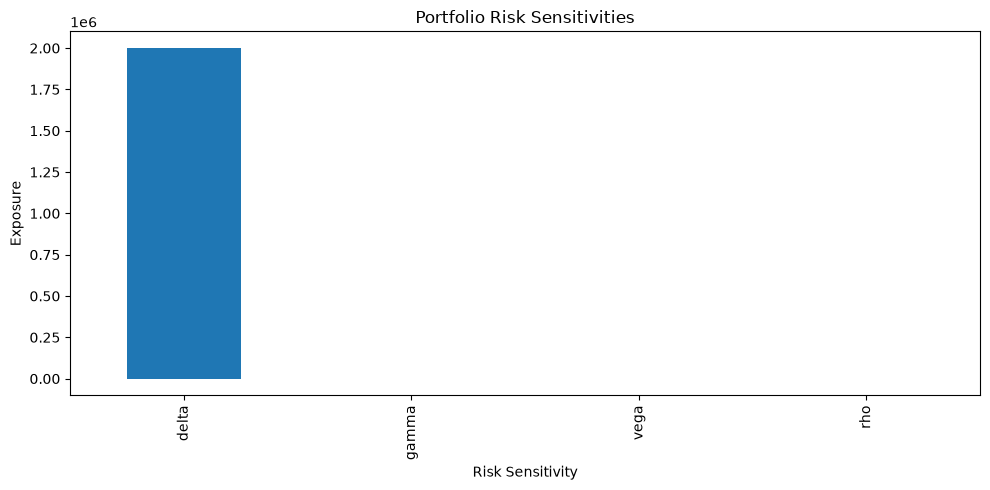

In [6]:
import matplotlib.pyplot as plt

greek_values = portfolio_risk[
    [
        "delta",
        "gamma",
        "vega",
        "rho",
    ]
].sum()

plt.figure(figsize=(10, 5))

greek_values.plot(
    kind="bar"
)

plt.title(
    "Portfolio Risk Sensitivities"
)

plt.xlabel(
    "Risk Sensitivity"
)

plt.ylabel(
    "Exposure"
)

plt.tight_layout()

plt.show()

In [7]:
portfolio_risk[
    [
        "trade_id",
        "delta",
    ]
].sort_values(
    "delta",
    ascending=False,
)

,trade_id,delta
7,FX001,2.000000e+06
0,EQ001,1.000000e+03
2,EQ003,7.500000e+02
3,OPT001,1.669841e+01
4,OPT002,1.411328e+00
6,BND001,0.000000e+00
5,OPT003,-8.076977e+00
1,EQ002,-5.000000e+02


In [8]:
portfolio_risk[
    [
        "trade_id",
        "gamma",
    ]
].sort_values(
    "gamma",
    ascending=False,
)

,trade_id,gamma
3,OPT001,0.060527
0,EQ001,0.000000
1,EQ002,0.000000
2,EQ003,0.000000
7,FX001,0.000000
6,BND001,0.000000
5,OPT003,-0.019489
4,OPT002,-0.031291


In [9]:
portfolio_risk[
    [
        "trade_id",
        "vega",
    ]
].sort_values(
    "vega",
    ascending=False,
)

,trade_id,vega
3,OPT001,1302.472056
0,EQ001,0.000000
1,EQ002,0.000000
2,EQ003,0.000000
7,FX001,0.000000
6,BND001,0.000000
4,OPT002,-673.345060
5,OPT003,-1760.485804


In [10]:
portfolio_risk[
    [
        "trade_id",
        "ir_dv01",
    ]
].sort_values(
    "ir_dv01",
)

,trade_id,ir_dv01
6,BND001,-4347.879229
0,EQ001,0.000000
2,EQ003,0.000000
1,EQ002,0.000000
3,OPT001,0.000000
4,OPT002,0.000000
5,OPT003,0.000000
7,FX001,0.000000


In [11]:
from src.risk.sensitivity_pnl import (
    estimate_portfolio_shock_pnl,
)

shock = {
    "AAPL": -0.10 * portfolio_risk.loc[
        portfolio_risk["underlying"] == "AAPL",
        "spot",
    ].mean(),

    "SPY": -0.10 * portfolio_risk.loc[
        portfolio_risk["underlying"] == "SPY",
        "spot",
    ].mean(),

    "MSFT": -0.10 * portfolio_risk.loc[
        portfolio_risk["underlying"] == "MSFT",
        "spot",
    ].mean(),

    "EURUSD": 0.0,
    "US10Y": 0.0,
}

In [12]:
shock_result = estimate_portfolio_shock_pnl(
    portfolio_risk,
    shock,
)

shock_result

,trade_id,underlying,estimated_pnl
0,EQ001,AAPL,-27233.868408
1,EQ002,SPY,34168.917847
2,EQ003,MSFT,-36398.906708
3,OPT001,AAPL,-432.316356
4,OPT002,AAPL,-50.039831
5,OPT003,SPY,506.454812
6,BND001,US10Y,0.000000
7,FX001,EURUSD,0.000000


In [13]:
shock_result["estimated_pnl"].sum()

np.float64(-29439.75864364795)